# Amazon Sales Data - Exploratory Data Analysis (EDA)

## Project Overview
This project analyzes 1,465 Amazon products to uncover insights about 
product categories, customer ratings, pricing, and discounts.
Prices have been converted to PKR for Pakistani market relevance.

## Business Question
**What makes a product successful on Amazon?**

## Author
Mehak Naseem

In [34]:
df.shape

(1465, 16)

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


In [36]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [37]:
df = df.dropna()
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [38]:
INR_TO_PKR = 3.04
df['discounted_price_pkr'] = df['discounted_price'] * INR_TO_PKR
df['actual_price_pkr'] = df['actual_price'] * INR_TO_PKR

print("Currency converted successfully!")
print(df[['product_name', 'actual_price', 'actual_price_pkr']].head())

TypeError: can't multiply sequence by non-int of type 'float'

In [ ]:
print(df['discounted_price'].dtype)
print(df['discounted_price'].head())

str
0    ₹399
1    ₹199
2    ₹199
3    ₹329
4    ₹154
Name: discounted_price, dtype: str


In [ ]:
df['discounted_price'] = df['discounted_price'].str.replace('₹','').str.replace(',','').str.strip().astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹','').str.replace(',','').str.strip().astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%','').str.strip().astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

AttributeError: Can only use .str accessor with string values, not floating

In [ ]:
print(df['discounted_price'].dtype)
(df['discounted_price'].head())

float64


0    399.0
1    199.0
2    199.0
3    329.0
4    154.0
Name: discounted_price, dtype: float64

In [ ]:
INR_TO_PKR = 3.04                                           
df['discounted_price_pkr'] = df['discounted_price'] * INR_TO_PKR    
df['actual_price_pkr'] = df['actual_price'] * INR_TO_PKR   
print("Currency converted successfully!")
print(df[['product_name', 'actual_price', 'actual_price_pkr']].head()) 

Currency converted successfully!
                                        product_name  actual_price  \
0  Wayona Nylon Braided USB to Lightning Fast Cha...        1099.0   
1  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...         349.0   
2  Sounce Fast Phone Charging Cable & Data Sync U...        1899.0   
3  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...         699.0   
4  Portronics Konnect L 1.2M Fast Charging 3A 8 P...         399.0   

   actual_price_pkr  
0           3340.96  
1           1060.96  
2           5772.96  
3           2124.96  
4           1212.96  


In [ ]:
df['category'].value_counts().head(10)

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                        231
Electronics|WearableTechnology|SmartWatches                                                               76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones                                      68
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                             63
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                                              52
Electronics|HomeTheater,TV&Video|Accessories|RemoteControls                                               49
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|MixerGrinders                                  27
Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables                                            24
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice                            24
Home&Kitch

In [ ]:
df['main_category'] = df['category'].str.split('|').str[0]
df['main_category'].value_counts().head(10)

main_category
Electronics              526
Computers&Accessories    451
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

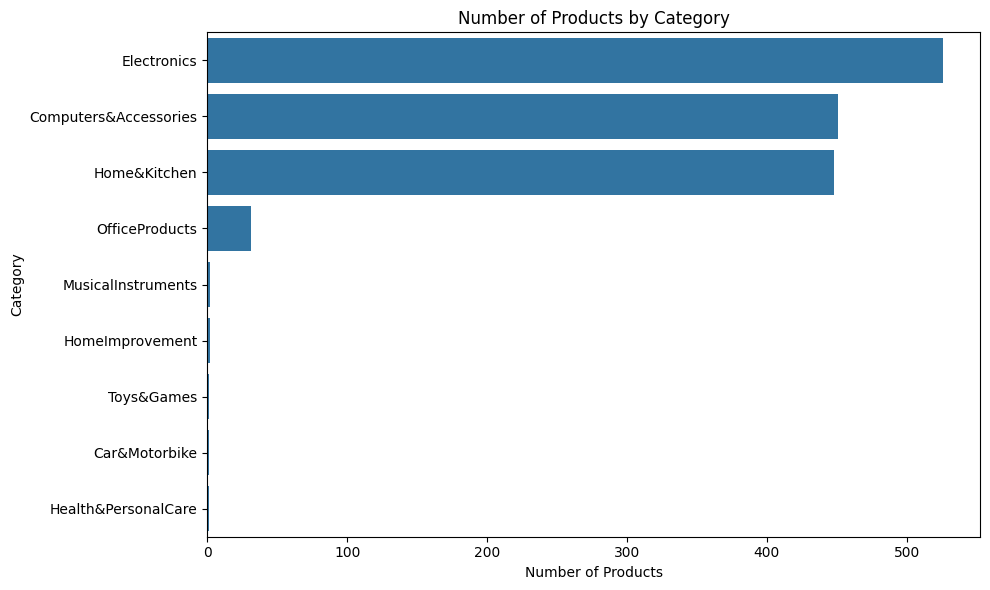

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='main_category', order=df['main_category'].value_counts().index)
plt.title('Number of Products by Category')
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('main_category')['rating'].mean().sort_values(ascending=False)

TypeError: dtype 'str' does not support operation 'mean'

In [ ]:
df['rafting'] = pd.to_numeric(df['rating'], errors='coerce')
print(df['rating'].dtype)
print(df['rafting'].head())


str
0    4.2
1    4.0
2    3.9
3    4.2
4    4.2
Name: rafting, dtype: float64


In [ ]:
df.groupby('main_category')['rating'].mean().sort_values(ascending=False)

TypeError: dtype 'str' does not support operation 'mean'

In [ ]:
print(df['rating'].dtype)

str


In [ ]:
df['rating'] = df['rating'].astype(str).str.strip().replace('|', None)
df['rating'] = pd.to_numeric(df['rating'], errors = 'coerce')
print(df['rating'].dtype)

float64


In [ ]:
df.groupby('main_category')['rating'].mean().sort_values(ascending=False)


main_category
OfficeProducts           4.309677
Toys&Games               4.300000
HomeImprovement          4.250000
Computers&Accessories    4.155654
Electronics              4.081749
Home&Kitchen             4.040716
Health&PersonalCare      4.000000
MusicalInstruments       3.900000
Car&Motorbike            3.800000
Name: rating, dtype: float64

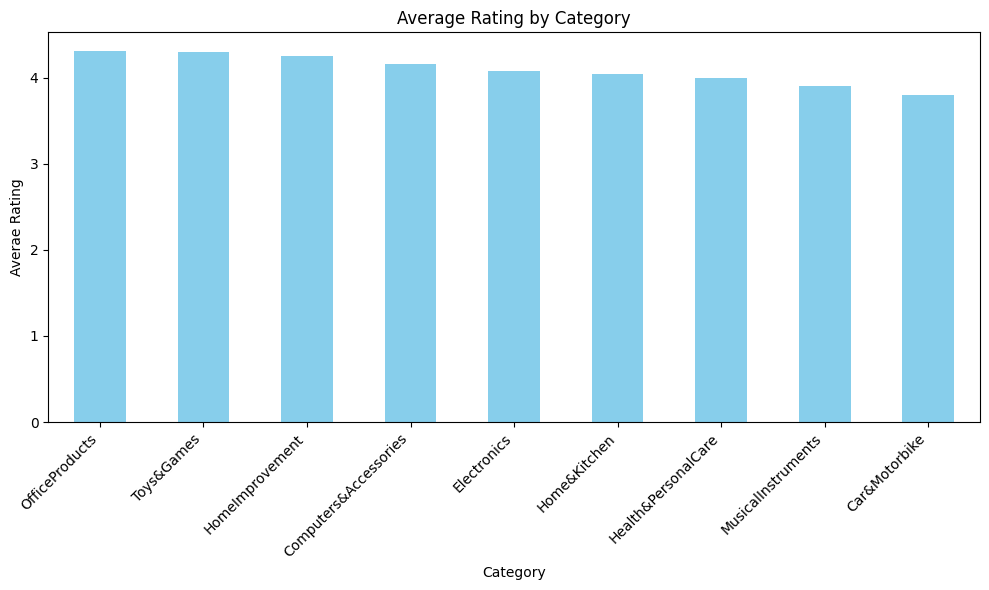

In [ ]:
df.groupby('main_category')['rating'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(10,6), color='skyblue')
plt.title('Average Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.ylabel('Averae Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

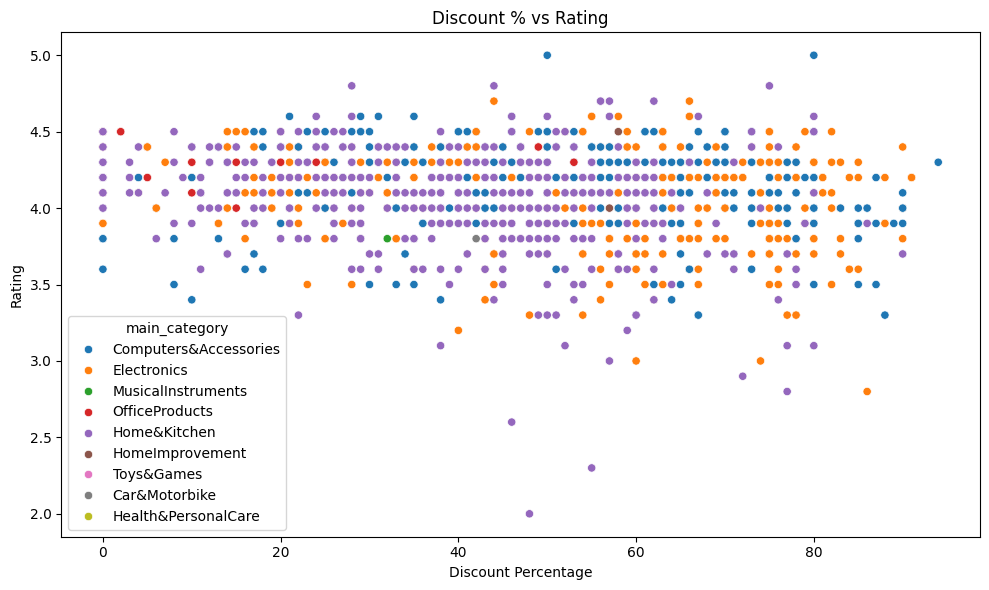

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='discount_percentage', y='rating', hue='main_category')
plt.title('Discount % vs Rating')
plt.xlabel('Discount Percentage')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

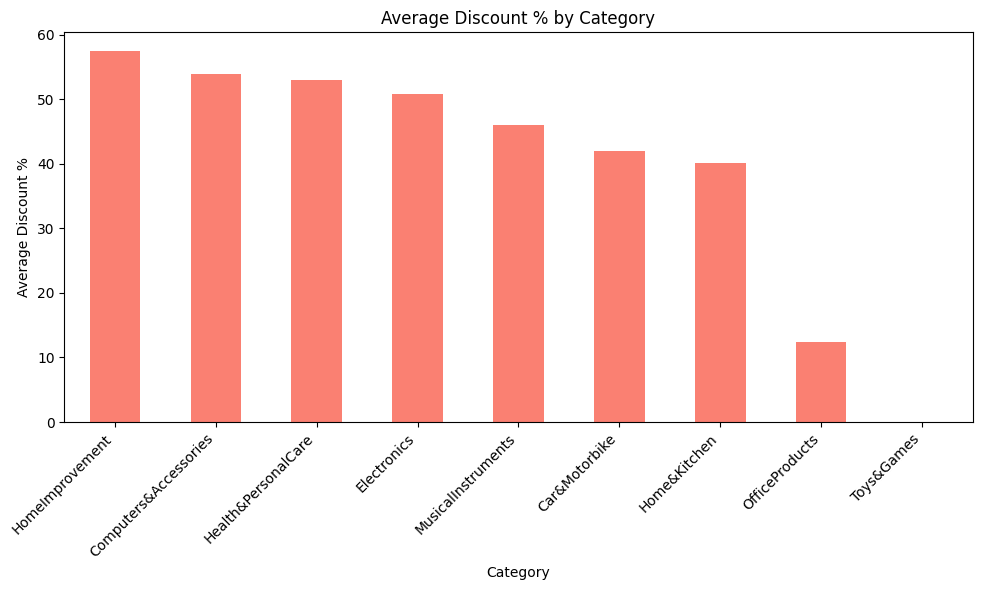

In [ ]:
df.groupby('main_category')['discount_percentage'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(10,6), color='salmon')
plt.title('Average Discount % by Category')
plt.xlabel('Category')
plt.ylabel('Average Discount %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Key Insights from Amazon Sales EDA

1. **Electronics** is the most listed category with 526 products
2. **Office Products** has the highest average customer rating of 4.31
3. **Discount percentage does NOT affect ratings** - customers rate based on quality not price
4. **Home Improvement** offers the highest average discount among all categories
5. Prices have been converted from INR to PKR (1 INR = 3.04 PKR) for Pakistani market relevance

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

## Dataset Source
- Kaggle - Amazon Sales Dataset